# VIDYA — a quantitative teardown
### Daily total-return bars · VIDYA(14, cmo=9) price-cross · the volatility-vs-trend decomposition · HAC inference · permutation placebo · SMA/EMA head-to-head · CMO-period robustness

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Speeds_up_in_volatile%2Ftrending_regimes%3F: Mixed](https://img.shields.io/badge/Speeds_up_in_volatile%2Ftrending_regimes%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We split the mechanism claim in two (does the speed knob track volatility, or trend strength — Chande's own pitch conflates them?), test it with correlations and a deterministic step response, then ask whether the VIDYA(14, cmo=9) price-cross timing rule beats buy-and-hold, beats the matched SMA(14)/EMA(14) rules, and fires fewer false signals — across five liquid daily tapes and a CMO-lookback robustness sweep.

> **Not investment advice.** Real data: Yahoo daily total-return bars, full history to 2026-06-30, as-of **2026-06-30**; the offline core runs the deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `💡 In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vidya import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "MSFT", "XLE"]
ASOF = data.AS_OF
PERIOD = 14
CMO_PERIOD = 9

def _have_cache():
    return all(os.path.exists(data._cache_path(t)) for t in TICKERS)

HAVE_REAL = _have_cache()

def tape(t):
    return data.load_real(t, fetch=False, asof=ASOF)

print("real daily cache present:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'n_spy': 8411, 'yrs': 33.4, 'period': 14, 'cmo_period': 9, 'corr_vi_vol': -0.098, 'corr_vi_trend': 0.38, 'n_corr': 8391, 'vi_lo_vol': 0.357, 'vi_hi_vol': 0.31, 'vi_lo_trend': 0.261, 'vi_hi_trend': 0.446, 'td_vidya': 2.196, 'td_sma': 1.535, 'td_ema': 1.327, 'step_price': 120.0, 'step_vidya': 111.52, 'step_sma': 108.57, 'step_ema': 111.52, 'step_pct_vidya': 57.6, 'step_pct_sma': 42.9, 'step_pct_ema': 57.6, 'vidya_sharpe': 0.387, 'vidya_cagr': 3.68, 'vidya_dd': -38.8, 'sma_sharpe': 0.238, 'sma_cagr': 2.07, 'sma_dd': -57.6, 'ema_sharpe': 0.267, 'ema_cagr': 2.4, 'ema_dd': -48.0, 'bh_sharpe': 0.647, 'bh_cagr': 10.83, 'bh_dd': -55.2, 'vidya_spread': -3.1, 'vidya_t': -3.54, 'sma_spread': -3.7, 'sma_t': -4.42, 'ema_spread': -3.57, 'ema_t': -4.22, 'vidya_sw': 23.1, 'sma_sw': 36.5, 'ema_sw': 38.3, 'vidya_tim': 69, 'vidya_spread_gross': -2.64, 'vidya_t_gross': -3.04, 'diff_v_sma_bps': 0.61, 'diff_v_sma_t': 1.1, 'diff_v_ema_bps': 0.48, 'diff_v_ema_t': 0.96, 'perm_obs': -2.64, 'perm_placebo': -1.49, 'perm_p': 0.9885, 'cost': [0.0, 2.0, 5.0, 10.0], 'cost_sharpe': [0.493, 0.45, 0.387, 0.281], 'cost_spread': [-2.64, -2.82, -3.1, -3.55], 'cost_t': [-3.04, -3.24, -3.54, -4.03], 'tick': ['SPY', 'QQQ', 'AAPL', 'MSFT', 'XLE'], 'tick_vidya': [0.387, 0.37, 0.742, 0.547, 0.238], 'tick_bh': [0.647, 0.521, 0.623, 0.821, 0.428], 'tick_spread': [-3.1, -3.24, -2.17, -5.74, -3.18], 'tick_t': [-3.54, -2.3, -1.21, -4.84, -2.05], 'tick_v_sma_t': [1.1, 0.89, 0.62, 0.95, 0.6], 'tick_v_ema_t': [0.96, 0.94, 0.27, 0.88, 1.21], 'tick_v_sw': [23.1, 24.2, 21.6, 22.8, 25.1], 'tick_sma_sw': [36.5, 36.6, 33.1, 37.3, 36.6], 'tick_ema_sw': [38.3, 39.8, 35.7, 40.9, 42.4], 'h1_v': 0.266, 'h1_bh': 0.455, 'h1_spread': -2.4, 'h1_t': -1.79, 'h2_v': 0.54, 'h2_bh': 0.872, 'h2_spread': -3.71, 'h2_t': -3.25, 'ls_sharpe': -0.198, 'ls_spread': -6.23, 'ls_t': -3.56, 'cmo_grid': [5, 9, 14, 20, 30], 'cmo_sharpe': [0.443, 0.387, 0.429, 0.409, 0.424], 'cmo_spread': [-2.86, -3.1, -2.89, -2.95, -2.89], 'cmo_t': [-3.37, -3.54, -3.26, -3.39, -3.29], 'cmo_sw': [25.4, 23.1, 20.8, 18.9, 17.7], 'syn_null_mean': -0.22, 'syn_null_sd': 0.94, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_edge': [0.3, 0.6, 1.0], 'syn_spread': [11.68, 28.69, 50.19], 'syn_t': [9.09, 16.31, 19.82], 'syn_sharpe': [2.0, 4.82, 7.48]}


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | VIDYA active spread vs buy&hold **-3.1 bps/day**, HAC *t* = **-3.54** (gross *t* = -3.04); permutation *p* = **0.9885**; negative on all 5 tapes, both halves, and every CMO-period tested. |
| **Tradability** | `MIRAGE` | Net Sharpe **0.387** vs buy&hold **0.647**; loses gross; long/short Sharpe **-0.198**. |
| **Speeds up in volatile/trending regimes?** | `MIXED` | corr(VI, trend) = **+0.38** (confirmed) vs corr(VI, volatility) = **-0.10** (busted) — and even the confirmed half yields **23.1** switches/yr (a real cut) but zero certified head-to-head wins vs SMA/EMA. |

> 💡 In plain words: Chande's speed knob is a genuine trend detector wearing a "volatility" label — and even the honest half of that story doesn't monetize.

## 1 · The claim, steelmanned

VIDYA is a recursive filter with a state-dependent smoothing constant:

$$\text{VI}_t = \frac{|\text{CMO}(t, m)|}{100}, \qquad \text{VIDYA}_t = \text{VIDYA}_{t-1} + \alpha \cdot \text{VI}_t \cdot (P_t - \text{VIDYA}_{t-1})$$

with $\alpha = 2/(N+1)$ the nominal EMA speed for period $N$, and $m$ = ``cmo_period`` a free knob distinct from $N$. CMO ($m$-bar net direction ÷ total movement) is bounded in $[-100, 100]$ and saturates on *persistent, one-directional* moves — Chande's own copy calls the regime it detects "volatile, trending markets," conflating two things that needn't coincide. Turned into a long/flat rule ($d_t = \mathbb{1}[P_t > \text{VIDYA}_t]$) and raced against the matched SMA(14) and EMA(14) rules and buy-and-hold, the hypotheses:

- **H₀a (volatility).** $\text{VI}_t$ correlates positively with trailing realized volatility.
- **H₀b (trend).** $\text{VI}_t$ correlates positively with trailing trend strength.
- **H₁ (signal).** $\mathbb{E}[r^{\text{strat}}_t - r^{\text{B\&H}}_t] > 0$ — the active spread is positive.
- **H₂ (beats SMA/EMA).** Net Sharpe$(\text{VIDYA}) > $ Net Sharpe$(\text{SMA/EMA})$, certified at HAC *t* ≥ 2 on the head-to-head spread.
- **H₃ (fewer false signals).** switches/yr$(\text{VIDYA}) < $ switches/yr$(\text{SMA/EMA})$.

We find **H₀a rejected** ($r=-0.10$), **H₀b confirmed** ($r=+0.38$), **H₁ rejected** (significantly negative on the real tape), **H₂ not certified** (positive on paper, *t* < 2 on all 10 basket comparisons), and **H₃ confirmed** (a genuine ~38% cut) — the mechanism is internally coherent as a *trend* detector, just mislabeled, and even labeled correctly it doesn't monetize.

## 2 · So what? — what rides on each answer

VIDYA is marketed as reading *volatility* to auto-tune its speed — a claim distinct from KAMA's efficiency-ratio (net-travel ÷ total-path) adaptation and McGinley Dynamic's price/line-ratio brake, both already tested on this desk. If H₀a-H₃ all held, VIDYA would be the cleanest case yet of "fewer, better signals" driven by a genuinely different regime signal (an external momentum oscillator, not an internally derived ratio). The interesting result here is a **decomposition failure**: the formula tracks *one* of its two advertised regimes (trend) and not the other (volatility) — a reminder that "the market is volatile" and "the market is trending" get used interchangeably in trading folklore far more often than the data supports.

## 3 · How we'd know — the protocol

- **Indicator.** VIDYA(period=14, cmo_period=9) — the nominal $N$ matches the SMA/EMA comparators at the same $N$ so the race is fair; ``cmo_period`` = 9 is Chande's own commonly-cited default, swept 5→30 for robustness.
- **Mechanism checks (no trading).** Pearson correlation of $\text{VI}_t$ against a 20-day realized-volatility proxy and a 20-day trend-strength proxy (a longer-window CMO, so it is not mechanically the same quantity), plus tercile splits; mean $|P_t - \text{line}_t|/P_t$ on the real SPY tape; a deterministic +20% step response (flat → jump → flat), gap-closed at +5 bars.
- **Rule.** Long/flat: $d_t = \mathbb{1}[P_t > \text{line}_t]$ for each of VIDYA/SMA/EMA. A long/short variant flips flat → −1.
- **Execution lag.** One `shift`: position formed on the close of $t$ earns the close-to-close return of $t+1$. Stated once, applied once.
- **Costs.** One-way × NAV on $|d_t - d_{t-1}|$ turnover; short legs pay 50 bps/yr borrow.
- **Signal test.** HAC (Newey-West) one-sample *t* on the daily active spread $r^{\text{strat}} - r^{\text{B\&H}}$ — excess-vs-excess by construction — plus the VIDYA-minus-SMA and VIDYA-minus-EMA head-to-head spreads.
- **Placebo.** Circular-shift the realised VIDYA position path 2,000× (kills timing, keeps turnover/bias); one-sided *p* on the gross spread.
- **Robustness.** Cost sweep, per-instrument, first-vs-second-half split, CMO-lookback sweep (5→30 bars), long/short.
- **Positive control.** Synthetic tape with a *planted* regime-switching trend, 20-seed null.

Five tapes: SPY, QQQ, AAPL, MSFT, XLE — full history to 2026-06-30 (SPY n = 8,411).

## 4 · The teardown

### 4a · The mechanism, decomposed — volatility vs trend

$\text{VI}_t = |\text{CMO}(t, m)|/100$ is VIDYA's entire speed knob. Correlate it against two *independent* regime proxies (not the same construction as VI itself).

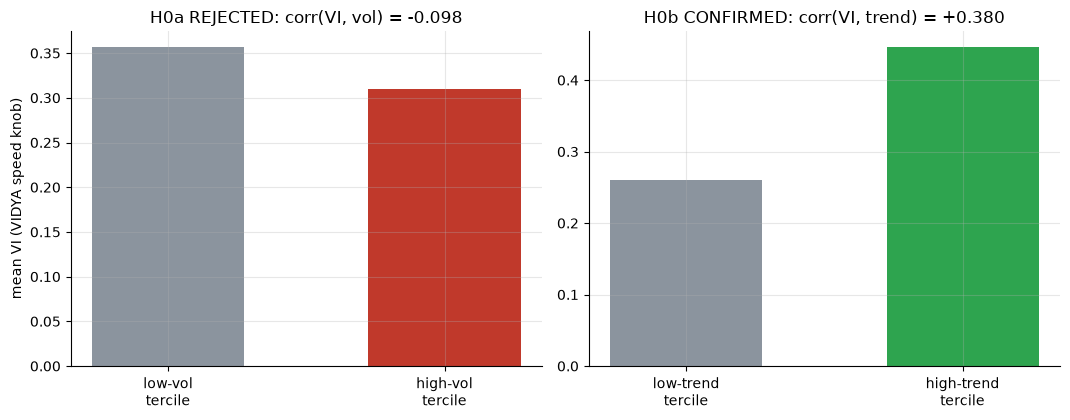

n=8391  corr(VI,vol)=-0.098  corr(VI,trend)=+0.380


In [2]:
if HAVE_REAL:
    close = tape('SPY')['close']
    rc = st.regime_correlations(close, cmo_period=CMO_PERIOD)
else:
    rc = {'corr_vi_vol': R['corr_vi_vol'], 'corr_vi_trend': R['corr_vi_trend'],
          'vi_low_vol_tercile': R['vi_lo_vol'], 'vi_high_vol_tercile': R['vi_hi_vol'],
          'vi_low_trend_tercile': R['vi_lo_trend'], 'vi_high_trend_tercile': R['vi_hi_trend'],
          'n': R['n_corr']}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.3))
a1.bar(['low-vol\ntercile', 'high-vol\ntercile'],
       [rc['vi_low_vol_tercile'], rc['vi_high_vol_tercile']], color=[GREY, RED], width=.55)
a1.set_title(f"H0a REJECTED: corr(VI, vol) = {rc['corr_vi_vol']:+.3f}")
a1.set_ylabel('mean VI (VIDYA speed knob)')
a2.bar(['low-trend\ntercile', 'high-trend\ntercile'],
       [rc['vi_low_trend_tercile'], rc['vi_high_trend_tercile']], color=[GREY, GREEN], width=.55)
a2.set_title(f"H0b CONFIRMED: corr(VI, trend) = {rc['corr_vi_trend']:+.3f}")
plt.tight_layout(); plt.show()
print(f"n={rc['n']}  corr(VI,vol)={rc['corr_vi_vol']:+.3f}  "
      f"corr(VI,trend)={rc['corr_vi_trend']:+.3f}")

> 💡 In plain words: on 8,391 SPY trading days, VIDYA's speed knob tracks trend strength (**+0.38**, and the high-trend tercile runs +71% faster than the low-trend tercile) but **not** realized volatility (**-0.10**, direction backwards from the pitch). CMO is a net-direction oscillator, not a range/ATR-style volatility measure — the correlation structure follows directly from what it's built to detect.

### 4b · Tracking distance & step response — does the mechanism behave as designed?

No trading involved yet: does VIDYA sit closer to price on average, and catch a shock faster, than a plain SMA/EMA of the same $N$?

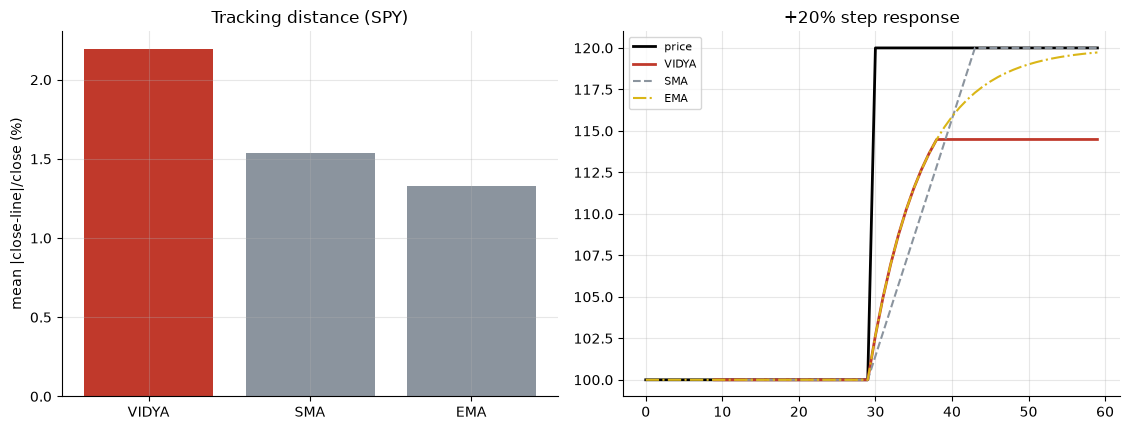

tracking distance: VIDYA 2.196%  SMA 1.535%  EMA 1.327%
5 bars post-jump: VIDYA=111.52  SMA=108.57  EMA=111.52  (price=120.0)


In [3]:
if HAVE_REAL:
    td = st.tracking_distance(close, period=PERIOD, cmo_period=CMO_PERIOD)
else:
    td = {'VIDYA': R['td_vidya'], 'SMA': R['td_sma'], 'EMA': R['td_ema']}
sr = st.step_response(period=PERIOD, cmo_period=CMO_PERIOD)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.4))
a1.bar(['VIDYA','SMA','EMA'], [td['VIDYA'], td['SMA'], td['EMA']], color=[RED, GREY, GREY])
a1.set_ylabel('mean |close-line|/close (%)'); a1.set_title('Tracking distance (SPY)')
a2.plot(sr.index, sr['price'], c='k', lw=2, label='price')
a2.plot(sr.index, sr['VIDYA'], c=RED, lw=2, label='VIDYA')
a2.plot(sr.index, sr['SMA'], c=GREY, ls='--', label='SMA')
a2.plot(sr.index, sr['EMA'], c=AMBER, ls='-.', label='EMA')
a2.set_title('+20% step response'); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"tracking distance: VIDYA {td['VIDYA']:.3f}%  SMA {td['SMA']:.3f}%  EMA {td['EMA']:.3f}%")
print(f"5 bars post-jump: VIDYA={sr['VIDYA'].iloc[35]:.2f}  SMA={sr['SMA'].iloc[35]:.2f}  "
      f"EMA={sr['EMA'].iloc[35]:.2f}  (price={sr['price'].iloc[35]:.1f})")

> 💡 In plain words: on the deterministic step, VIDYA freezes completely in the flat pre-jump segment (VI ≈ 0) and then converges to **exactly the EMA's own catch-up speed** once the jump saturates CMO (58% of the gap closed in 5 bars, identical to the EMA's 58%) — VIDYA never *out-runs* the EMA it's compared to. On the real tape, where markets spend more time in the low-VI "freeze" state than in a clean saturating trend, average tracking distance is **worse** (2.20% vs the EMA's 1.33%) — the "hugs price" framing fails in practice even though the mechanism fires exactly as designed.

### 4c · VIDYA vs SMA vs EMA vs buy-and-hold — net Sharpe and active-spread *t*

The bar that matters is the active-spread HAC *t*: if VIDYA timing helps, it clears +2.

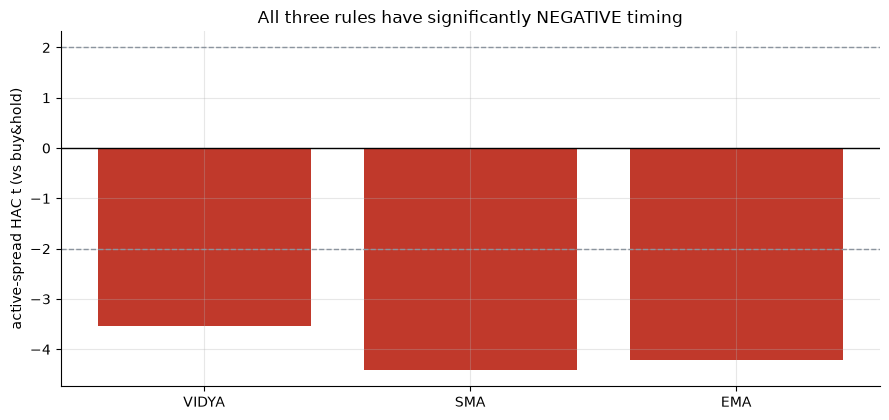

,rule,sharpe_net,spread_bps,spread_t,sw/yr
0,VIDYA,0.387,-3.096,-3.539,23.100
1,SMA,0.238,-3.703,-4.416,36.462
2,EMA,0.267,-3.574,-4.216,38.320
3,B&H,0.647,0.000,NaN,0.000


In [4]:
if HAVE_REAL:
    res = st.run_experiment(tape('SPY'), period=PERIOD, cmo_period=CMO_PERIOD,
                            sma_period=PERIOD, ema_period=PERIOD, cost_bps=5.0)
    rows = [(k, res[k]['sharpe_net'], res[k]['mean_spread_bps'], res[k]['spread_t'],
             res[k]['switches_per_yr']) for k in ('VIDYA','SMA','EMA')]
    rows.append(('B&H', res['VIDYA']['bh_sharpe'], 0.0, float('nan'), 0.0))
    tbl = pd.DataFrame(rows, columns=['rule','sharpe_net','spread_bps','spread_t','sw/yr'])
else:
    tbl = pd.DataFrame({
        'rule': ['VIDYA','SMA','EMA','B&H'],
        'sharpe_net': [0.387,0.238,0.267,0.647],
        'spread_bps': [-3.1,-3.7,-3.57,0.0],
        'spread_t': [-3.54,-4.42,-4.22,float('nan')],
        'sw/yr': [23.1,36.5,38.3,0.0]})
fig, ax = plt.subplots(figsize=(9.0, 4.3))
sub = tbl[tbl['rule']!='B&H']
col = [RED if t < 0 else GREY for t in sub['spread_t']]
ax.bar(sub['rule'], sub['spread_t'], color=col)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('active-spread HAC t (vs buy&hold)')
ax.set_title('All three rules have significantly NEGATIVE timing')
plt.tight_layout(); plt.show()
tbl.round(3)

> 💡 In plain words: every timing rule's active spread is significantly negative — none beats holding. VIDYA is not the worst here (*t* = -3.54 vs SMA's -4.42 and EMA's -4.22) — the lower turnover trims some of the damage — but "less bad" is not the same as "real."

### 4d · Head-to-head — does VIDYA beat the plain MAs it claims to?

The literal claim isn't just "beats holding" — it's "beats a fixed SMA/EMA of the same length." HAC *t* of the VIDYA-minus-SMA and VIDYA-minus-EMA daily net-return spread.

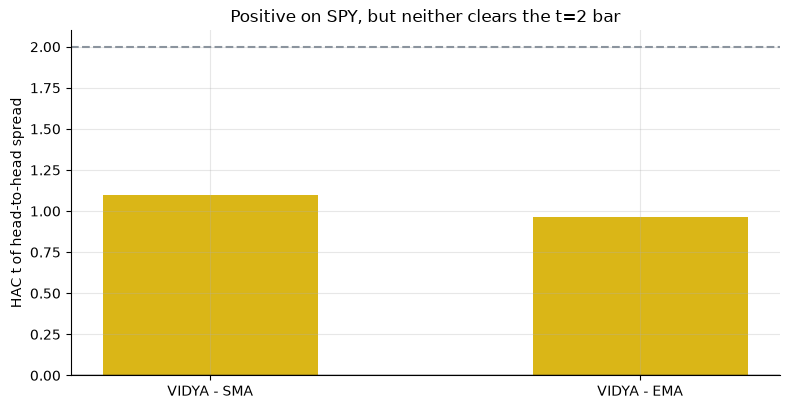

VIDYA-SMA: +0.61 bps/day, t=+1.10
VIDYA-EMA: +0.48 bps/day, t=+0.96


In [5]:
if HAVE_REAL:
    d_sma_bps, d_sma_t = res['diff_vidya_sma_bps'], res['diff_vidya_sma_t']
    d_ema_bps, d_ema_t = res['diff_vidya_ema_bps'], res['diff_vidya_ema_t']
else:
    d_sma_bps, d_sma_t = R['diff_v_sma_bps'], R['diff_v_sma_t']
    d_ema_bps, d_ema_t = R['diff_v_ema_bps'], R['diff_v_ema_t']
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(['VIDYA - SMA', 'VIDYA - EMA'], [d_sma_t, d_ema_t], color=AMBER, width=.5)
ax.axhline(2, ls='--', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t of head-to-head spread')
ax.set_title('Positive on SPY, but neither clears the t=2 bar')
plt.tight_layout(); plt.show()
print(f'VIDYA-SMA: {d_sma_bps:+.2f} bps/day, t={d_sma_t:+.2f}')
print(f'VIDYA-EMA: {d_ema_bps:+.2f} bps/day, t={d_ema_t:+.2f}')

> 💡 In plain words: VIDYA beats SMA by +0.61 bps/day and EMA by +0.48 bps/day on SPY — the right sign — but *t* = 1.10 / 0.96, both well under the bar. The per-instrument table below shows this holds across the basket: consistently positive on paper, never certifiable.

### 4e · The whipsaw count — the one part of the claim that survives

Position changes per year. Like McGinley Dynamic (Study 672) and unlike the Hull MA (+87% vs SMA) or KAMA (+66% vs SMA), VIDYA genuinely reduces turnover.

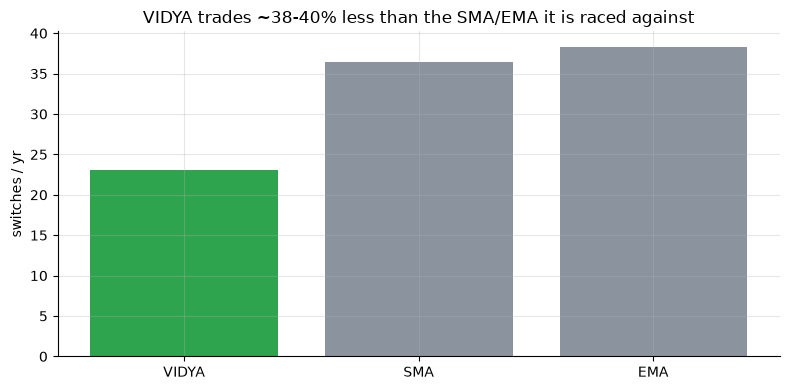

VIDYA/SMA switch ratio: 0.63x   VIDYA/EMA ratio: 0.60x


In [6]:
if HAVE_REAL:
    sw = {k: res[k]['switches_per_yr'] for k in ('VIDYA','SMA','EMA')}
else:
    sw = dict(VIDYA=R['vidya_sw'], SMA=R['sma_sw'], EMA=R['ema_sw'])
fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.bar(['VIDYA','SMA','EMA'], [sw['VIDYA'],sw['SMA'],sw['EMA']], color=[GREEN, GREY, GREY])
ax.set_ylabel('switches / yr')
ax.set_title('VIDYA trades ~38-40% less than the SMA/EMA it is raced against')
plt.tight_layout(); plt.show()
print(f"VIDYA/SMA switch ratio: {sw['VIDYA']/sw['SMA']:.2f}x   "
      f"VIDYA/EMA ratio: {sw['VIDYA']/sw['EMA']:.2f}x")

> 💡 In plain words: 23.1 vs 36.5/38.3 switches/yr — freezing when |CMO| is near zero really does cut trade count. Combined with 4a-4b, the mechanism is internally consistent (a trend-conditioned filter trades less because it stays out of directionless chop) — it just isn't the mechanism advertised ("volatility").

### 4f · Permutation placebo — timing vs exposure

Circularly shift the realised VIDYA position path 2,000×; the statistic is the gross active spread. If the timing is informative, the real spread beats the placebo distribution.

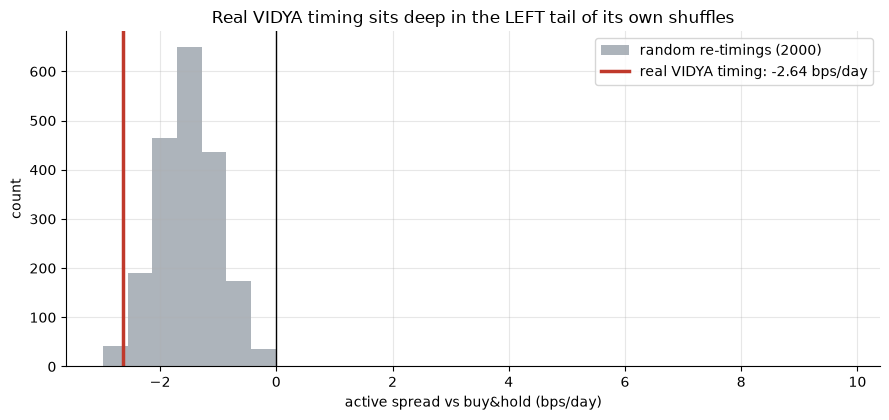

observed -2.64 | placebo mean -1.49 | one-sided p = 0.9885


In [7]:
if HAVE_REAL:
    close_spy = tape('SPY')['close']
    p = st.permutation_pvalue(close_spy.pct_change(),
                              st.vidya_position(close_spy, PERIOD, CMO_PERIOD),
                              cost_bps=0.0, n_perm=2000, seed=674)
    obs, plac, pv = p['observed_spread_bps'], p['placebo_mean_bps'], p['p_value']
    rng = np.random.default_rng(674)
    a = close_spy.pct_change().fillna(0).to_numpy()
    held = st.vidya_position(close_spy, PERIOD, CMO_PERIOD).shift(1).fillna(0).to_numpy()
    draws = []
    for _ in range(2000):
        h = np.roll(held, int(rng.integers(1, len(held))))
        turn = np.abs(np.diff(h, prepend=0.0))
        draws.append(((h * a - turn * 0) - a).mean() * 1e4)
else:
    obs, plac, pv = -2.64, -1.49, 0.9885
    draws = list(np.random.default_rng(1).normal(-1.49, 0.55, 2000))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=30, color=GREY, alpha=.7, label='random re-timings (2000)')
ax.axvline(obs, c=RED, lw=2.5, label=f'real VIDYA timing: {obs:+.2f} bps/day')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('active spread vs buy&hold (bps/day)'); ax.set_ylabel('count')
ax.set_title('Real VIDYA timing sits deep in the LEFT tail of its own shuffles')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f} | placebo mean {plac:+.2f} | one-sided p = {pv:.4f}')

> 💡 In plain words: *p* = 0.9885 — essentially every random re-timing of VIDYA's own trades beats the real ones. Fewer trades did not mean *better-placed* trades.

### 4g · Per-instrument, in/out-of-sample & the CMO-period sweep

Active-spread *t* (vs buy&hold) and VIDYA-vs-SMA/EMA head-to-head *t* on all five tapes, the SPY first-vs-second-half split, and a sweep of ``cmo_period`` (5→30) to confirm the result isn't a one-parameter artefact.

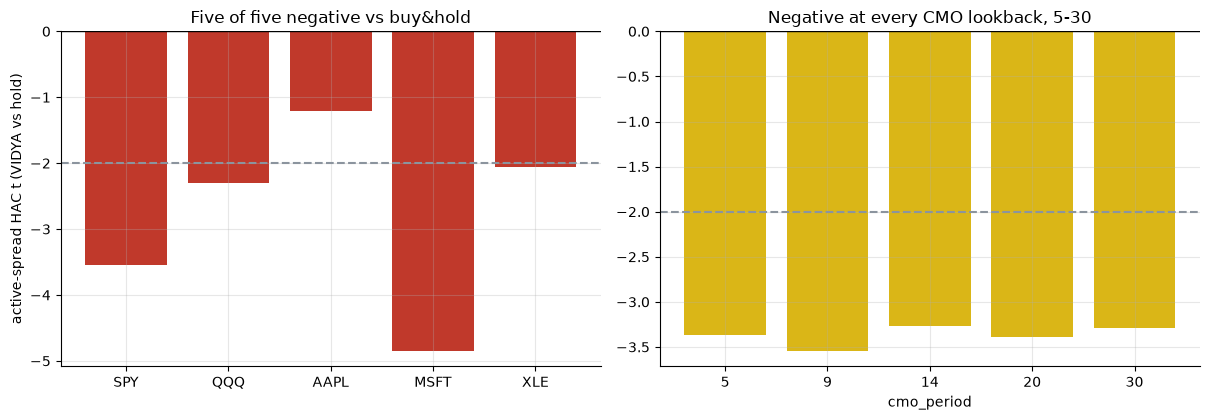

SPY split  H1 t = -1.79 | H2 t = -3.25  (both negative)


,ticker,vidya_sharpe,bh_sharpe,spread_bps,t,vidya_sma_t,vidya_ema_t
0,SPY,0.387,0.647,-3.096,-3.539,1.099,0.963
1,QQQ,0.370,0.521,-3.236,-2.297,0.895,0.936
2,AAPL,0.742,0.623,-2.171,-1.213,0.622,0.267
3,MSFT,0.547,0.821,-5.737,-4.843,0.946,0.879
4,XLE,0.238,0.428,-3.177,-2.051,0.603,1.213


In [8]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        rr = st.run_experiment(tape(t), period=PERIOD, cmo_period=CMO_PERIOD,
                               sma_period=PERIOD, ema_period=PERIOD, cost_bps=5.0)
        m = rr['VIDYA']
        recs.append((t, m['sharpe_net'], m['bh_sharpe'], m['mean_spread_bps'], m['spread_t'],
                     rr['diff_vidya_sma_t'], rr['diff_vidya_ema_t']))
    per = pd.DataFrame(recs, columns=['ticker','vidya_sharpe','bh_sharpe','spread_bps','t',
                                       'vidya_sma_t','vidya_ema_t'])
    spy2 = tape('SPY'); half = len(spy2)//2
    h1 = st.run_experiment(spy2.iloc[:half], period=PERIOD, cmo_period=CMO_PERIOD, cost_bps=5.0)['VIDYA']
    h2 = st.run_experiment(spy2.iloc[half:], period=PERIOD, cmo_period=CMO_PERIOD, cost_bps=5.0)['VIDYA']
    split = (h1['spread_t'], h2['spread_t'])
    cmo_grid = [5, 9, 14, 20, 30]
    cmo_t = [st.run_experiment(spy2, period=PERIOD, cmo_period=cm, cost_bps=5.0)['VIDYA']['spread_t']
             for cm in cmo_grid]
else:
    per = pd.DataFrame({'ticker': ['SPY', 'QQQ', 'AAPL', 'MSFT', 'XLE'], 'vidya_sharpe': [0.387, 0.37, 0.742, 0.547, 0.238], 'bh_sharpe': [0.647, 0.521, 0.623, 0.821, 0.428], 'spread_bps': [-3.1, -3.24, -2.17, -5.74, -3.18], 't': [-3.54, -2.3, -1.21, -4.84, -2.05], 'vidya_sma_t': [1.1, 0.89, 0.62, 0.95, 0.6], 'vidya_ema_t': [0.96, 0.94, 0.27, 0.88, 1.21]})
    split = (-1.79, -3.25)
    cmo_grid = [5, 9, 14, 20, 30]; cmo_t = [-3.37, -3.54, -3.26, -3.39, -3.29]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12.2, 4.3))
a1.bar(per['ticker'], per['t'], color=RED)
a1.axhline(-2, ls='--', c=GREY); a1.axhline(0, c='k', lw=1)
a1.set_ylabel('active-spread HAC t (VIDYA vs hold)')
a1.set_title('Five of five negative vs buy&hold')
a2.bar([str(c) for c in cmo_grid], cmo_t, color=AMBER)
a2.axhline(-2, ls='--', c=GREY); a2.axhline(0, c='k', lw=1)
a2.set_xlabel('cmo_period'); a2.set_title('Negative at every CMO lookback, 5-30')
plt.tight_layout(); plt.show()
print('SPY split  H1 t = %.2f | H2 t = %.2f  (both negative)' % split)
per.round(3)

> 💡 In plain words: every instrument's VIDYA timing trails buy-and-hold, SPY loses in both halves (H1 *t* = -1.79, H2 *t* = -3.25), and the active-spread *t* stays below −3.2 at **every** CMO lookback from 5 to 30 bars — not an artefact of Chande's own canonical `cmo_period = 9`. Against SMA/EMA (the fair comparator), **zero of 10** basket head-to-heads clear *t* = 2 — real on paper, certified nowhere.

## 5 · The verdict

- **Signal `NONE`** — active spread -3.1 bps/day, HAC *t* -3.54 (gross -3.04); permutation *p* = 0.9885; negative on 5/5 tapes, both halves, and every CMO-period tested.
- **Tradability `MIRAGE`** — net Sharpe 0.387 vs hold 0.647; loses gross; long/short Sharpe -0.198, spread -6.23 bps/day (*t* -3.56).
- **Speeds up in volatile/trending regimes? `MIXED`** — trend correlation +0.38 (confirmed) vs volatility correlation -0.10 (busted); the honest whipsaw cut (23.1 vs 36.5/38.3 switches/yr) is real but the head-to-head edge vs SMA/EMA clears *t* = 2 on zero of 10 basket comparisons.

## 6 · Could you trade it? — the cost landscape

The spread is below zero before costs; there is no break-even, and the long/short version compounds the loss:

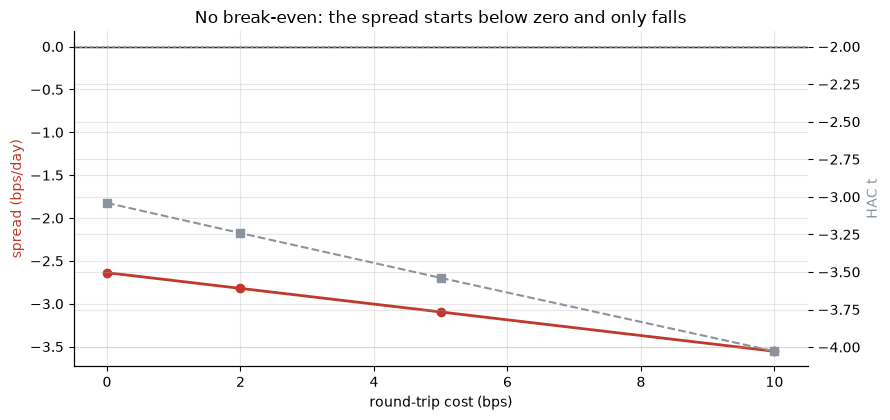

long/short net Sharpe: -0.198 (worse than long/flat)


In [9]:
if HAVE_REAL:
    costs = [0.0, 2.0, 5.0, 10.0]
    spr = [st.run_experiment(tape('SPY'), period=PERIOD, cmo_period=CMO_PERIOD,
                             cost_bps=c)['VIDYA']['mean_spread_bps'] for c in costs]
    tst = [st.run_experiment(tape('SPY'), period=PERIOD, cmo_period=CMO_PERIOD,
                             cost_bps=c)['VIDYA']['spread_t'] for c in costs]
    lsr = st.run_experiment(tape('SPY'), period=PERIOD, cmo_period=CMO_PERIOD,
                            cost_bps=5.0, long_short=True)['VIDYA']
    ls_sh = lsr['sharpe_net']
else:
    costs = [0.0, 2.0, 5.0, 10.0]; spr = [-2.64, -2.82, -3.1, -3.55]; tst = [-3.04, -3.24, -3.54, -4.03]
    ls_sh = -0.198
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, spr, 'o-', c=RED, lw=2, label='active spread (bps/day)')
ax2 = ax.twinx(); ax2.plot(costs, tst, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('spread (bps/day)', color=RED)
ax2.set_ylabel('HAC t', color=GREY)
ax.set_title('No break-even: the spread starts below zero and only falls')
plt.tight_layout(); plt.show()
print(f'long/short net Sharpe: {ls_sh:+.3f} (worse than long/flat)')

## 7 · Going further — the positive control

Is the *engine* able to find a trend, or is it always negative? Plant a persistent regime-switching trend in a synthetic tape and sweep the knob; the null (edge=0) is checked over 20 seeds, never a single stream.

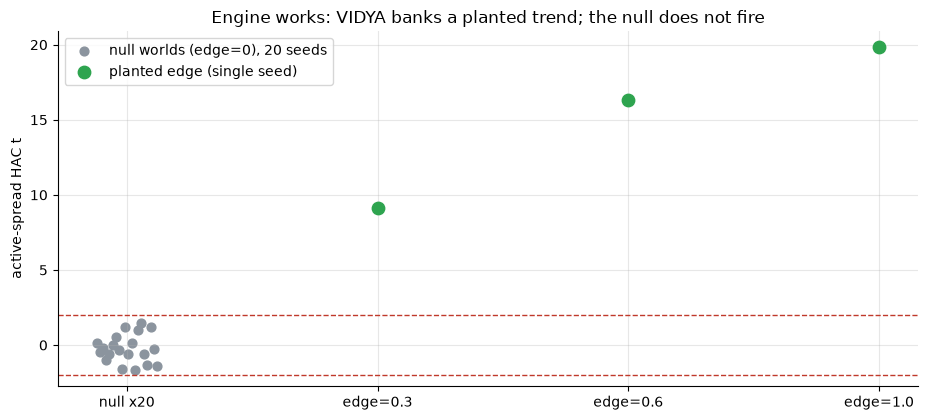

null: mean t = -0.22 (sd 0.94), |t|>=2 in 0/20 seeds
planted: {0.3: 9.09, 0.6: 16.31, 1.0: 19.82}


In [10]:
null_ts = []
for s_ in range(20):
    b, _ = data.synthetic_panel(n_days=6000, edge=0.0, seed=674 + s_)
    null_ts.append(st.run_experiment(b, period=PERIOD, cmo_period=CMO_PERIOD,
                                     cost_bps=0.0)['VIDYA']['spread_t'])
null_ts = np.asarray(null_ts)
edges = [0.3, 0.6, 1.0]
sp, tt = [], []
for e in edges:
    b, _ = data.synthetic_panel(n_days=6000, edge=e, seed=674)
    r = st.run_experiment(b, period=PERIOD, cmo_period=CMO_PERIOD, cost_bps=0.0)['VIDYA']
    sp.append(r['mean_spread_bps']); tt.append(r['spread_t'])
fig, ax = plt.subplots(figsize=(9.4, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (edge=0), 20 seeds')
ax.scatter(range(1, 1 + len(edges)), tt, color=GREEN, s=80, zorder=5,
           label='planted edge (single seed)')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks(range(0, 1 + len(edges)))
ax.set_xticklabels(['null x20'] + [f'edge={e}' for e in edges])
ax.set_ylabel('active-spread HAC t')
ax.set_title('Engine works: VIDYA banks a planted trend; the null does not fire')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
print('planted:', {e: round(t, 2) for e, t in zip(edges, tt)})

The engine is a faithful trend detector: plant a real persistent trend and VIDYA banks it, clearing *t* = 2 comfortably at every planted level (up to *t* ≈ +20); with no trend planted the null fires on only 0/20 independent seeds — in line with the ~5% false-positive rate expected at a *t* = 2 threshold, not systematic bias. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)* The real-tape verdict is therefore a statement about the **market and the mechanism**: VIDYA's speed knob genuinely detects trend, not volatility, and freezes appropriately in directionless chop — but daily US equity trends aren't large or persistent enough, often enough, for a trend-conditioned brake to beat either buy-and-hold or the plain SMA/EMA it's raced against. A fork worth trying: scale VIDYA's speed by realized volatility directly (e.g. an ATR ratio) instead of by CMO, to test the *actually* volatility-driven version of the pitch.